In [3]:
# Biblioteca padrão do Python para interagir com o sistema operacional
# Usada para manipular arquivos, caminhos de diretórios, listar pastas, etc.
import os

# Biblioteca principal para computação com tensores e deep learning
# Permite utilizar GPU e construir modelos de redes neurais
import torch

# Módulo do PyTorch que contém camadas e componentes para construir redes neurais
# Ex: Linear, Conv2d, ReLU, etc.
import torch.nn as nn

# Módulo do PyTorch usado para algoritmos de otimização
# Responsável por atualizar os pesos da rede durante o treinamento
import torch.optim as optim

# Biblioteca de visão computacional muito usada para processamento de imagens
# Permite ler, modificar, redimensionar e manipular imagens
import cv2

# Biblioteca fundamental para computação científica em Python
# Muito usada para manipular arrays, matrizes e operações matemáticas
import numpy as np

# Biblioteca para criação de gráficos e visualizações
# Usada para mostrar imagens, resultados de treinamento, loss, etc.
import matplotlib.pyplot as plt

# Classes do PyTorch para criação de datasets personalizados e carregamento de dados
# Dataset -> define como os dados são organizados
# DataLoader -> carrega os dados em batches para treinamento
from torch.utils.data import Dataset, DataLoader

# Módulo da torchvision que fornece transformações para imagens
# Ex: normalização, redimensionamento, conversão para tensor, data augmentation
from torchvision import transforms

# Biblioteca para manipulação de imagens em Python
# Muito usada junto com torchvision para carregar e processar imagens
from PIL import Image

In [ ]:
!pip install opencv-python matplotlib pillow tqdm scikit-learn

In [19]:
# Criamos uma classe chamada MRIDataset que herda da classe Dataset do PyTorch.
# Isso permite criar um dataset personalizado para carregar imagens de ressonância
# magnética (MRI) e suas respectivas máscaras de segmentação.
class MRIDataset(Dataset):

    # Método construtor da classe (executado quando o dataset é criado)
    def __init__(self, image_dir, mask_dir, transform=None):

        # Caminho da pasta onde estão armazenadas as imagens MRI
        # Exemplo: dataset/images
        self.image_dir = image_dir

        # Caminho da pasta onde estão armazenadas as máscaras
        # As máscaras são imagens que indicam onde estão as regiões de interesse
        # (ex: lesões, tumores, etc.)
        self.mask_dir = mask_dir

        # Lista todos os arquivos dentro da pasta de imagens
        # Isso cria uma lista com o nome de cada arquivo
        # Exemplo: ["img_1.png", "img_2.png", ...]
        self.images = os.listdir(image_dir)

        # Transformações que podem ser aplicadas nas imagens
        # Exemplos:
        # - Converter para tensor
        # - Normalizar valores
        # - Redimensionar imagens
        # - Data augmentation
        self.transform = transform


    # Método obrigatório do Dataset
    # Retorna o tamanho total do dataset (quantidade de imagens)
    # Isso permite ao PyTorch saber quantos dados existem no dataset
    def __len__(self):

        # Retorna o número total de imagens encontradas na pasta
        return len(self.images)


    # Método responsável por carregar um item específico do dataset
    # O DataLoader chama esse método várias vezes durante o treinamento
    # para carregar os dados em batches
    def __getitem__(self, index):

        # Constrói o caminho completo da imagem utilizando:
        # - pasta das imagens
        # - nome do arquivo na posição "index"
        img_path = os.path.join(self.image_dir, self.images[index])

        # Constrói o caminho da máscara correspondente
        # Aqui assumimos que o nome da máscara segue um padrão parecido
        # com o da imagem, apenas substituindo "img" por "mask"
        #
        # Exemplo:
        # img_001.png  -> mask_001.png
        mask_path = os.path.join(
            self.mask_dir,
            self.images[index].replace("img", "mask")
        )

        # Abre a imagem utilizando a biblioteca PIL
        # convert("L") converte a imagem para escala de cinza (grayscale)
        #
        # Isso é comum em exames de ressonância magnética,
        # pois geralmente eles possuem apenas um canal (1 channel)
        image = Image.open(img_path).convert("L")

        # Abre a máscara da mesma forma
        # A máscara geralmente contém valores indicando:
        # 0 = fundo
        # 1 = região de interesse (ex: lesão)
        mask = Image.open(mask_path).convert("L")

        # Se houver transformações definidas (ex: ToTensor, Resize etc.)
        # elas serão aplicadas tanto na imagem quanto na máscara
        #
        # Isso é importante para garantir que:
        # - imagem e máscara tenham o mesmo tamanho
        # - estejam no formato esperado pelo modelo
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Retornamos um par (image, mask)
        #
        # image -> imagem MRI de entrada
        # mask  -> máscara com a região segmentada
        #
        # Esse formato é usado no treinamento de modelos de segmentação
        # onde:
        # entrada  = imagem
        # saída esperada = máscara
        return image, mask

In [20]:
# Criamos um pipeline de transformações para as imagens
# O transforms.Compose permite aplicar várias transformações em sequência
# na ordem em que foram definidas
transform = transforms.Compose([

    # Redimensiona a imagem para 256x256 pixels
    # Isso é importante porque redes neurais precisam receber
    # entradas com tamanho fixo.
    #
    # Mesmo que as imagens originais tenham tamanhos diferentes,
    # todas serão convertidas para 256x256 antes de entrar no modelo.
    transforms.Resize((256,256)),

    # Converte a imagem para um Tensor do PyTorch
    #
    # Antes dessa etapa a imagem é um objeto PIL ou array de pixels.
    # Depois ela passa a ser um Tensor, que é o formato que o PyTorch usa
    # para realizar cálculos e treinar redes neurais.
    #
    # Essa transformação também:
    # - muda o formato de (H, W, C) para (C, H, W)
    # - normaliza os valores dos pixels de [0,255] para [0,1]
    transforms.ToTensor()

])

# CARREGANDO O DATASET

In [21]:
# Criamos uma instância do nosso dataset personalizado (MRIDataset)
# Aqui estamos informando:
# - onde estão as imagens
# - onde estão as máscaras
# - quais transformações devem ser aplicadas nos dados
dataset = MRIDataset(

    # Caminho da pasta que contém as imagens de ressonância magnética (MRI)
    # Essas imagens serão usadas como entrada da rede neural
    image_dir="dataset/images",

    # Caminho da pasta que contém as máscaras de segmentação
    # As máscaras representam o "gabarito" correto que o modelo deve aprender
    # (ex: regiões onde existem lesões)
    mask_dir="dataset/masks",

    # Pipeline de transformações definido anteriormente
    # Ele será aplicado tanto na imagem quanto na máscara
    # Exemplo: redimensionar para 256x256 e converter para tensor
    transform=transform
)


# Criamos um DataLoader a partir do dataset
# O DataLoader é responsável por:
# - carregar os dados automaticamente
# - dividir os dados em batches
# - embaralhar os dados durante o treinamento
# - otimizar o carregamento de dados
train_loader = DataLoader(

    # O dataset que criamos acima
    dataset,

    # Quantidade de imagens que serão processadas por vez
    # Cada batch terá 4 imagens e 4 máscaras
    #
    # Exemplo de batch retornado:
    # imagens -> tensor (4, 1, 256, 256)
    # masks   -> tensor (4, 1, 256, 256)
    batch_size=4,

    # Embaralha os dados a cada época de treinamento
    #
    # Isso é importante porque:
    # - evita que a rede memorize a ordem dos dados
    # - melhora a capacidade de generalização do modelo
    shuffle=True
)


# Exibe no console o número total de imagens no dataset
# O len(dataset) chama o método __len__() que criamos na classe MRIDataset
# que retorna a quantidade de arquivos na pasta de imagens
print("Total de imagens:", len(dataset))

Total de imagens: 787


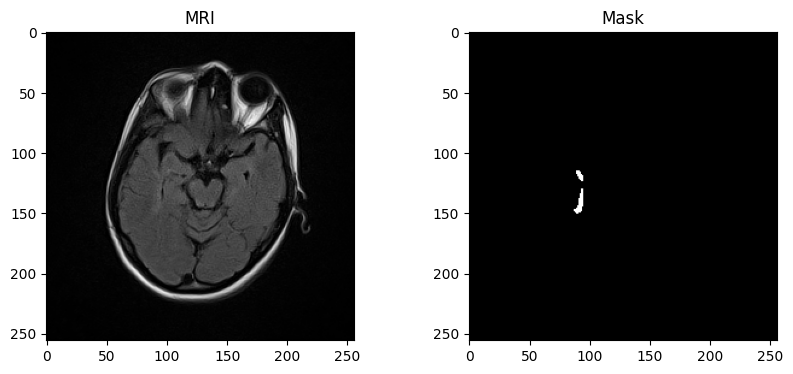

In [24]:
# Aqui estamos acessando diretamente um item do dataset
# dataset[10] chama o método __getitem__(10) que criamos na classe MRIDataset
#
# Isso retorna:
# img  -> a imagem MRI na posição 10
# mask -> a máscara correspondente da imagem
img, mask = dataset[10]


# Criamos uma figura usando matplotlib
# figsize define o tamanho da janela do gráfico (largura, altura)
# Nesse caso: 10 de largura e 4 de altura
plt.figure(figsize=(10,4))


# Criamos o primeiro gráfico dentro da figura
# subplot(linhas, colunas, posição)
#
# Aqui estamos criando uma grade com:
# 1 linha
# 2 colunas
# e selecionando o gráfico da posição 1
plt.subplot(1,2,1)

# Define o título do primeiro gráfico
plt.title("MRI")

# Exibe a imagem MRI
#
# img é um tensor no formato (1,256,256)
# A função squeeze() remove dimensões com tamanho 1
#
# Então:
# (1,256,256) -> (256,256)
#
# cmap="gray" define que a imagem será exibida em escala de cinza
plt.imshow(img.squeeze(), cmap="gray")


# Criamos o segundo gráfico
# mesma estrutura (1 linha, 2 colunas)
# posição 2
plt.subplot(1,2,2)

# Define o título do gráfico
plt.title("Mask")

# Exibe a máscara da segmentação
#
# A máscara representa as regiões onde existe a lesão
# Valores mais claros normalmente indicam a área segmentada
plt.imshow(mask.squeeze(), cmap="gray")


# Mostra a figura completa na tela
# sem esse comando os gráficos podem não aparecer
plt.show()

In [25]:
# Criamos uma classe chamada DoubleConv
# Ela herda de nn.Module, que é a classe base usada no PyTorch
# para construir modelos de redes neurais.
class DoubleConv(nn.Module):

    # Método construtor da classe
    # in_channels  -> número de canais de entrada da imagem ou feature map
    # out_channels -> número de canais que queremos gerar após as convoluções
    def __init__(self, in_channels, out_channels):

        # Inicializa a classe pai (nn.Module)
        # Isso é obrigatório ao criar módulos personalizados no PyTorch
        super().__init__()

        # Criamos um bloco de camadas sequenciais usando nn.Sequential
        # Isso permite empilhar várias camadas que serão executadas em ordem
        self.conv = nn.Sequential(

            # Primeira camada de convolução
            #
            # nn.Conv2d:
            # in_channels  -> canais da entrada
            # out_channels -> quantidade de filtros (feature maps gerados)
            # 3            -> tamanho do kernel (3x3)
            # padding=1    -> adiciona borda na imagem para manter o mesmo tamanho
            #
            # Exemplo:
            # entrada  (1,256,256)
            # saída    (64,256,256)  se out_channels = 64
            nn.Conv2d(in_channels, out_channels, 3, padding=1),

            # Função de ativação ReLU (Rectified Linear Unit)
            #
            # Introduz não-linearidade na rede
            # permitindo que ela aprenda padrões complexos.
            #
            # ReLU(x) = max(0, x)
            nn.ReLU(),

            # Segunda camada de convolução
            #
            # Agora a entrada já tem "out_channels" canais
            # e a saída mantém o mesmo número de canais
            #
            # Esse padrão de duas convoluções é muito usado na arquitetura UNet
            nn.Conv2d(out_channels, out_channels, 3, padding=1),

            # Outra ativação ReLU após a segunda convolução
            nn.ReLU()
        )


    # Método forward define como os dados passam pela rede
    # Toda vez que fazemos model(x), esse método é chamado
    def forward(self, x):

        # x -> tensor de entrada (imagem ou feature map)

        # Passamos o tensor pelo bloco de convoluções definido acima
        # e retornamos o resultado
        return self.conv(x)

In [26]:
# Criamos a classe UNet que herda de nn.Module
# Essa será a arquitetura da rede neural usada para segmentação
class UNet(nn.Module):

    # Método construtor da rede
    def __init__(self):
        super().__init__()

        # -------- ENCODER (CAMINHO DE CONTRAÇÃO) --------
        # Essa parte da rede extrai características da imagem
        # e reduz gradualmente a resolução espacial.

        # Primeiro bloco de convoluções
        # Entrada: 1 canal (imagem em grayscale)
        # Saída: 64 feature maps
        self.down1 = DoubleConv(1,64)

        # Camada de pooling que reduz a resolução pela metade
        # Ex: 256x256 -> 128x128
        self.pool1 = nn.MaxPool2d(2)

        # Segundo bloco de convoluções
        # Entrada: 64 canais
        # Saída: 128 canais
        self.down2 = DoubleConv(64,128)

        # Novo pooling para reduzir novamente
        # Ex: 128x128 -> 64x64
        self.pool2 = nn.MaxPool2d(2)


        # -------- BOTTLENECK --------
        # Parte central da rede onde as features são mais profundas
        # e abstratas

        # Aqui aumentamos ainda mais os canais
        # Entrada: 128
        # Saída: 256
        self.bottleneck = DoubleConv(128,256)


        # -------- DECODER (CAMINHO DE EXPANSÃO) --------
        # Agora a rede começa a aumentar a resolução novamente
        # para reconstruir a segmentação da imagem

        # ConvTranspose2d faz "upsampling"
        # ou seja, aumenta a resolução da imagem
        # Ex: 64x64 -> 128x128
        self.up1 = nn.ConvTranspose2d(256,128,2,2)

        # Após o upsample, concatenamos com features do encoder
        # então o número de canais dobra (128 + 128 = 256)
        self.conv1 = DoubleConv(256,128)

        # Novo upsampling
        # Ex: 128x128 -> 256x256
        self.up2 = nn.ConvTranspose2d(128,64,2,2)

        # Novamente concatenamos com features anteriores
        # 64 + 64 = 128 canais
        self.conv2 = DoubleConv(128,64)


        # -------- CAMADA FINAL --------
        # Reduz os canais para apenas 1 canal
        # que representará o mapa de segmentação
        self.out = nn.Conv2d(64,1,1)


    # Define como os dados passam pela rede
    def forward(self,x):

        # -------- ENCODER --------

        # Primeiro bloco de convoluções
        d1 = self.down1(x)

        # Redução de resolução
        p1 = self.pool1(d1)

        # Segundo bloco
        d2 = self.down2(p1)

        # Nova redução
        p2 = self.pool2(d2)


        # -------- BOTTLENECK --------

        # Extração profunda de features
        b = self.bottleneck(p2)


        # -------- DECODER --------

        # Upsampling
        u1 = self.up1(b)

        # Skip connection
        # Concatenamos as features do encoder com o decoder
        # Isso ajuda a preservar detalhes da imagem original
        u1 = torch.cat([u1,d2],dim=1)

        # Novo bloco de convolução
        u1 = self.conv1(u1)


        # Segundo upsampling
        u2 = self.up2(u1)

        # Nova skip connection
        u2 = torch.cat([u2,d1],dim=1)

        # Convolução final do decoder
        u2 = self.conv2(u2)


        # Camada final da rede
        # Conv2d reduz para 1 canal
        # Sigmoid transforma os valores em probabilidades (0 a 1)
        # representando a chance de cada pixel pertencer à lesão
        return torch.sigmoid(self.out(u2))

In [27]:
# Aqui verificamos se existe uma GPU disponível para uso
# torch.cuda.is_available() retorna True se houver uma GPU compatível com CUDA
#
# Se houver GPU -> usamos "cuda"
# Caso contrário -> usamos "cpu"
#
# Isso permite que o código rode tanto em computadores com GPU
# quanto em máquinas comuns sem GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Criamos uma instância do modelo UNet que definimos anteriormente
# Em seguida usamos .to(device) para mover o modelo para o dispositivo escolhido
#
# Se for GPU:
# o modelo será executado muito mais rápido
#
# Se for CPU:
# o modelo ainda funciona, mas o treinamento será mais lento
model = UNet().to(device)


# Definimos a função de perda (Loss Function)
#
# nn.BCELoss() = Binary Cross Entropy Loss
#
# Essa função é usada quando o problema é de classificação binária
# ou segmentação binária, onde cada pixel pode ser:
#
# 0 -> fundo
# 1 -> região de interesse (ex: lesão)
#
# A loss mede o erro entre:
# - a máscara prevista pelo modelo
# - a máscara real do dataset
criterion = nn.BCELoss()


# Criamos o otimizador responsável por atualizar os pesos da rede
#
# Adam é um dos algoritmos de otimização mais usados em Deep Learning
# porque ele combina:
# - Momentum
# - Adaptive Learning Rate
#
# model.parameters() -> todos os pesos e biases da rede
# lr=0.001 -> taxa de aprendizado (learning rate)
#
# O learning rate controla o tamanho do passo que a rede dá
# ao atualizar os pesos durante o treinamento
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Definimos o número de épocas de treinamento
# Uma época significa que o modelo verá TODO o dataset uma vez
epochs = 5

# Loop principal de treinamento
# O modelo será treinado durante "epochs" ciclos completos do dataset
for epoch in range(epochs):

    # Variável usada para acumular o erro total da época
    # Isso nos permite acompanhar se o modelo está aprendendo
    total_loss = 0

    # Percorremos o DataLoader que fornece os dados em batches
    # Cada iteração retorna:
    # images -> batch de imagens MRI
    # masks  -> máscaras correspondentes
    for images, masks in train_loader:

        # Movemos os tensores para o mesmo dispositivo do modelo
        # (GPU ou CPU)
        images = images.to(device)
        masks = masks.to(device)

        # Passamos as imagens pelo modelo
        # Isso executa o método forward() da UNet
        #
        # O modelo gera uma predição da máscara de segmentação
        outputs = model(images)

        # Calculamos o erro entre:
        # - a máscara prevista pelo modelo
        # - a máscara real do dataset
        #
        # Quanto menor o valor da loss, melhor o modelo está aprendendo
        loss = criterion(outputs, masks)

        # Zeramos os gradientes armazenados no otimizador
        #
        # Isso é necessário porque o PyTorch acumula gradientes
        # por padrão a cada backward()
        optimizer.zero_grad()

        # Backpropagation
        #
        # Calcula os gradientes da função de perda em relação
        # aos pesos da rede neural
        loss.backward()

        # Atualiza os pesos da rede usando o otimizador (Adam)
        # com base nos gradientes calculados
        optimizer.step()

        # Adicionamos o valor da loss atual ao total da época
        # loss.item() converte o tensor da loss para um número Python
        total_loss += loss.item()

    # Ao final de cada época mostramos o erro total acumulado
    # Isso ajuda a acompanhar o progresso do treinamento
    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 98.8734327480197
Epoch: 2 Loss: 100.9488972350955
Epoch: 3 Loss: 100.75063482299447
Epoch: 4 Loss: 100.91515199840069
Epoch: 5 Loss: 100.80261209234595


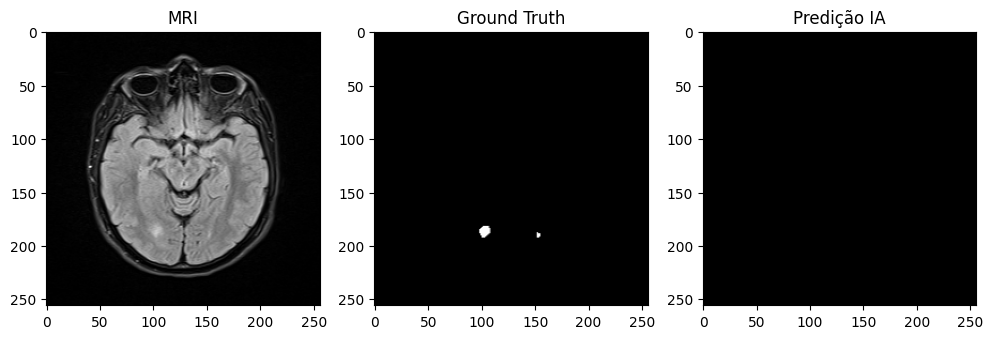

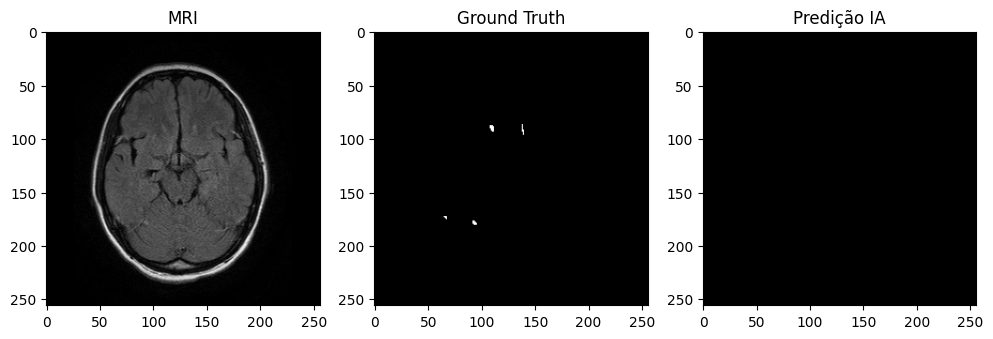

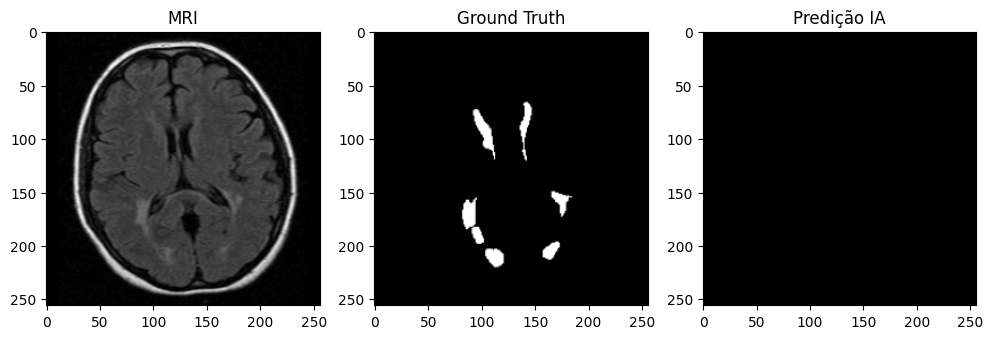

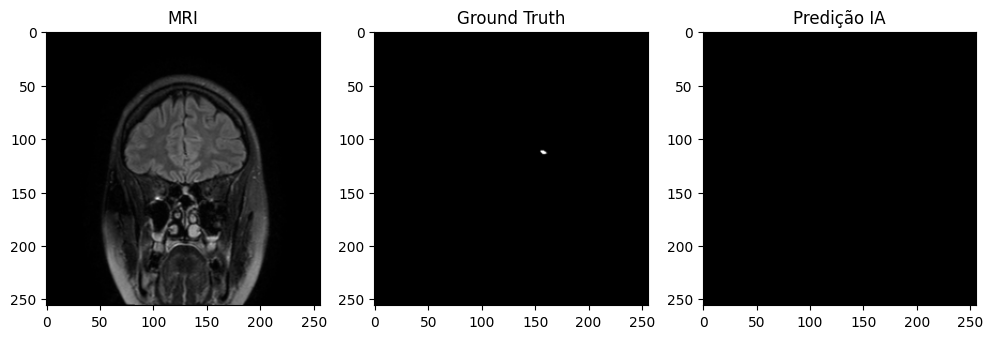

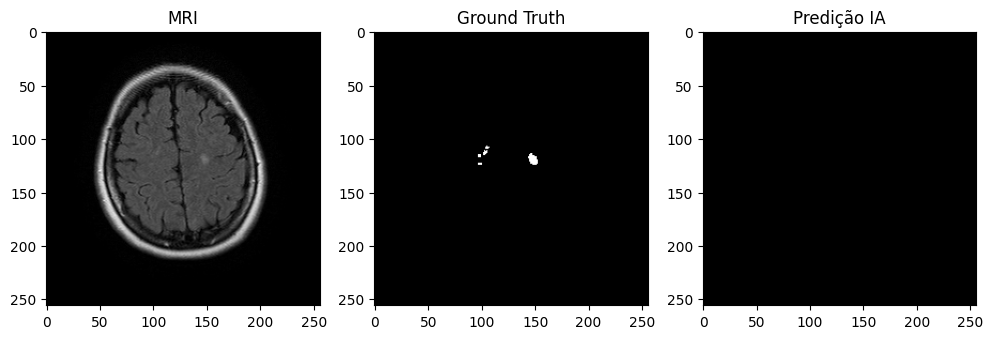

In [29]:
# Coloca o modelo em modo de avaliação
#
# Isso desativa comportamentos usados apenas no treinamento,
# como Dropout e atualizações do BatchNorm.
# Dessa forma, o modelo faz apenas inferência (previsões).
model.eval()


# Importamos a biblioteca random para escolher imagens aleatórias do dataset
import random


# Vamos visualizar 5 exemplos diferentes do dataset
for i in range(5):

    # Escolhe um índice aleatório entre 0 e o tamanho do dataset
    # Isso seleciona uma imagem aleatória para testar
    idx = random.randint(0, len(dataset)-1)

    # Pegamos a imagem e a máscara real (ground truth) correspondente
    img, mask = dataset[idx]


    # Desativamos o cálculo de gradientes
    #
    # Isso é importante durante a inferência porque:
    # - reduz uso de memória
    # - deixa a execução mais rápida
    # - não precisamos de gradientes pois não estamos treinando
    with torch.no_grad():

        # img.unsqueeze(0) adiciona uma dimensão de batch
        #
        # A rede espera entrada no formato:
        # (batch, canais, altura, largura)
        #
        # Antes:
        # (1,256,256)
        #
        # Depois:
        # (1,1,256,256)
        pred = model(img.unsqueeze(0).to(device))


    # Removemos dimensões extras do tensor
    # e movemos o resultado da GPU para a CPU
    pred = pred.squeeze().cpu().numpy()


    # Criamos uma figura para mostrar os resultados
    plt.figure(figsize=(12,4))


    # -------- PRIMEIRA IMAGEM --------
    # MRI original
    plt.subplot(1,3,1)
    plt.title("MRI")

    # squeeze remove dimensão do canal
    # mostrando apenas a matriz da imagem
    plt.imshow(img.squeeze(), cmap="gray")


    # -------- SEGUNDA IMAGEM --------
    # Máscara real (ground truth)
    plt.subplot(1,3,2)
    plt.title("Ground Truth")

    # Essa é a segmentação correta do dataset
    plt.imshow(mask.squeeze(), cmap="gray")


    # -------- TERCEIRA IMAGEM --------
    # Predição do modelo
    plt.subplot(1,3,3)
    plt.title("Predição IA")

    # pred > 0 transforma a saída da rede em máscara binária
    #
    # A rede gera probabilidades entre 0 e 1.
    # Aqui convertemos para:
    #
    # True (1) -> região da lesão
    # False (0) -> fundo
    plt.imshow(pred > 0, cmap="gray")


    # Mostra as três imagens lado a lado
    plt.show()

In [30]:
# Função que calcula o Dice Score entre a predição do modelo e a máscara real
#
# O Dice Score mede o quanto a área prevista pelo modelo
# coincide com a área real da segmentação.
#
# Valor do Dice Score:
# 0   -> nenhuma sobreposição
# 1   -> sobreposição perfeita
def dice_score(pred, target):

    # Converte a predição da rede em máscara binária
    #
    # A rede retorna probabilidades entre 0 e 1.
    # Aplicamos um threshold de 0.5 para decidir:
    #
    # > 0.5 → 1 (lesão)
    # <= 0.5 → 0 (fundo)
    #
    # .float() converte o resultado para tensor float
    pred = (pred > 0.5).float()


    # Calcula a interseção entre a predição e o alvo real
    #
    # Como as máscaras são binárias (0 ou 1),
    # multiplicar pred * target mantém apenas os pixels
    # onde ambos são 1 ao mesmo tempo.
    #
    # Depois usamos .sum() para contar esses pixels.
    intersection = (pred * target).sum()


    # Fórmula do Dice Score
    #
    # Dice = 2 * interseção / (soma_predição + soma_real)
    #
    # pred.sum()   -> número de pixels previstos como lesão
    # target.sum() -> número de pixels reais da lesão
    #
    # 1e-8 é um valor pequeno adicionado para evitar divisão por zero
    resultado = (2 * intersection) / (pred.sum() + target.sum() + 1e-8)


    # Mostra o valor calculado no console
    print("resultado:", resultado)


    # Retorna o Dice Score
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)

In [31]:
# Criamos uma lista vazia para armazenar os Dice Scores
# calculados para cada batch do dataset
dice_scores = []


# Colocamos o modelo em modo de avaliação
#
# Isso garante que camadas como Dropout e BatchNorm
# funcionem corretamente durante a inferência
model.eval()


# Desativamos o cálculo de gradientes
#
# Isso é importante porque:
# - estamos apenas avaliando o modelo
# - não precisamos calcular gradientes
# - economiza memória
# - torna a execução mais rápida
with torch.no_grad():

    # Percorremos todo o DataLoader
    # Cada iteração retorna um batch de imagens e máscaras
    for images, masks in train_loader:

        # Movemos os dados para o mesmo dispositivo do modelo
        # (GPU ou CPU)
        images = images.to(device)
        masks = masks.to(device)

        # Passamos as imagens pelo modelo
        # Isso gera a predição das máscaras
        outputs = model(images)

        # Calculamos o Dice Score comparando:
        # - predição da rede (outputs)
        # - máscara real (masks)
        dice = dice_score(outputs, masks)

        # Convertendo o tensor para número Python
        # usando .item() e adicionando na lista
        dice_scores.append(dice.item())


# Calculamos a média dos Dice Scores de todos os batches
# np.mean calcula a média dos valores armazenados na lista
print("Dice médio:", np.mean(dice_scores))

resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado: tensor(0.)
resultado:

In [32]:
torch.save(model.state_dict(), "unet_mri_model.pth")

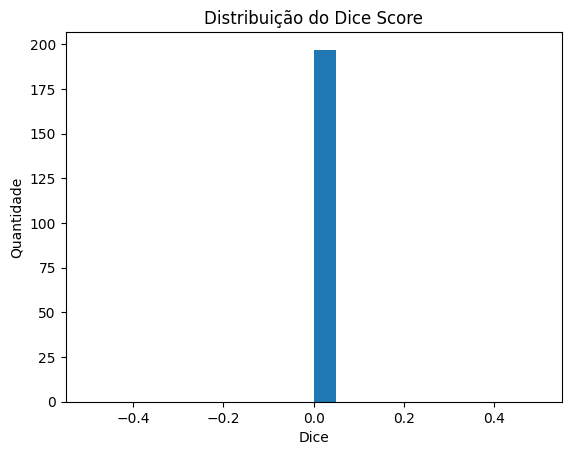

In [33]:
# Cria um histograma usando os valores de Dice Score armazenados na lista
#
# plt.hist() mostra a distribuição de frequência dos valores.
# Cada barra representa quantas vezes um intervalo de Dice Score apareceu.
#
# bins=20 significa que o eixo será dividido em 20 intervalos (faixas)
# para analisar melhor a distribuição dos resultados do modelo.
plt.hist(dice_scores, bins=20)


# Define o título do gráfico
# Isso ajuda a identificar rapidamente o que está sendo analisado.
plt.title("Distribuição do Dice Score")


# Define o rótulo do eixo X
# Aqui mostramos que o eixo horizontal representa os valores de Dice Score.
plt.xlabel("Dice")


# Define o rótulo do eixo Y
# Representa quantas amostras caíram em cada intervalo do histograma.
plt.ylabel("Quantidade")


# Exibe o gráfico na tela
plt.show()

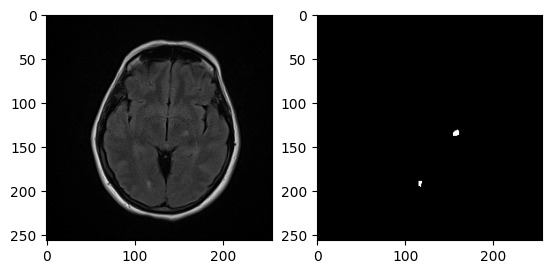

In [34]:
# Pegamos a primeira amostra do dataset
#
# dataset[0] chama o método __getitem__(0) da classe MRIDataset
# Isso retorna:
# img  -> imagem de ressonância magnética
# mask -> máscara da segmentação correspondente
img, mask = dataset[0]


# Criamos o primeiro gráfico dentro de uma grade de subplots
#
# subplot(linhas, colunas, posição)
#
# Aqui estamos criando:
# 1 linha
# 2 colunas
# posição 1 (primeiro gráfico)
plt.subplot(1,2,1)

# Mostra a imagem MRI
#
# img é um tensor no formato (1, altura, largura)
# A função squeeze() remove dimensões com tamanho 1
#
# (1,256,256) -> (256,256)
#
# cmap="gray" define que a imagem será exibida em escala de cinza
# (padrão para imagens médicas)
plt.imshow(img.squeeze(), cmap="gray")


# Criamos o segundo gráfico da mesma grade
# posição 2
plt.subplot(1,2,2)

# Mostra a máscara de segmentação
#
# A máscara indica a região da imagem que contém
# a estrutura ou lesão que queremos detectar.
#
# Normalmente:
# 0 -> fundo
# 1 -> região de interesse
plt.imshow(mask.squeeze(), cmap="gray")

#   VERIFICANDO SE TEM GPU

In [25]:
import torch
print(torch.cuda.is_available())

False


# CONTINUAR TREINAMENTO

In [11]:
# Criamos uma nova instância da arquitetura da rede neural
#
# É necessário recriar o modelo com a mesma arquitetura usada
# durante o treinamento, pois os pesos salvos pertencem a essa estrutura.
model = UNet()  # ou qualquer arquitetura que você definiu anteriormente


# Carregamos os pesos do modelo que foram salvos em arquivo
#
# torch.load() lê o arquivo .pth que contém os parâmetros treinados
# da rede neural (pesos e biases).
#
# map_location=device garante que os pesos sejam carregados
# corretamente no dispositivo atual (CPU ou GPU).
#
# Isso é importante porque às vezes o modelo foi treinado em GPU
# mas pode estar sendo carregado em uma máquina sem GPU.
model.load_state_dict(torch.load("unet_mri_model.pth", map_location=device))


# Movemos o modelo para o dispositivo definido anteriormente
# (CPU ou GPU).
#
# Isso garante que os cálculos do modelo ocorrerão no mesmo
# dispositivo onde os dados serão processados.
model.to(device)


# Colocamos o modelo em modo de treinamento
#
# Isso ativa comportamentos específicos de treinamento,
# como:
# - Dropout
# - atualização do BatchNorm
#
# Esse modo deve ser usado quando vamos continuar treinando o modelo.
model.train()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (up1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))


In [14]:
!pip install tqdm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from tqdm import tqdm  # biblioteca para barra de progresso

# Definimos quantas épocas queremos continuar treinando
#
# epochs = 1 significa que o modelo verá todo o dataset
# mais uma vez para ajustar os pesos.
#
# Você pode aumentar esse valor para continuar melhorando o modelo.
epochs = 1  # ou mais, se quiser continuar


# Loop principal de treinamento
# Cada iteração representa uma época completa no dataset
for epoch in range(epochs):

    # Variável para acumular o erro total da época
    # Isso ajuda a acompanhar se o modelo está melhorando
    total_loss = 0

    # tqdm cria uma barra de progresso no loop
    # total=len(train_loader) define o tamanho da barra
    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")

    # Percorremos o DataLoader que fornece os dados em batches
    #
    # Cada batch contém:
    # images -> conjunto de imagens MRI
    # masks  -> máscaras reais correspondentes
    for images, masks in loop:

        # Movemos os dados para o mesmo dispositivo do modelo
        # (CPU ou GPU)
        images = images.to(device)
        masks = masks.to(device)


        # Passamos as imagens pelo modelo
        #
        # Isso executa o método forward() da UNet
        # gerando uma predição das máscaras
        outputs = model(images)


        # Calculamos a função de perda (loss)
        #
        # Aqui comparamos:
        # outputs -> predição do modelo
        # masks   -> máscara real
        #
        # Quanto menor a loss, melhor o modelo está aprendendo
        loss = criterion(outputs, masks)


        # Zeramos os gradientes anteriores
        #
        # PyTorch acumula gradientes por padrão,
        # então precisamos limpar antes de calcular novos
        optimizer.zero_grad()


        # Backpropagation
        #
        # Calcula os gradientes da loss em relação
        # aos pesos da rede neural
        loss.backward()


        # Atualiza os pesos da rede
        #
        # O otimizador (Adam) usa os gradientes calculados
        # para ajustar os parâmetros do modelo
        optimizer.step()


        # Adiciona o valor da loss atual ao total da época
        #
        # loss.item() converte o tensor da loss para número Python
        total_loss += loss.item()
        
        # Atualiza informações mostradas na barra
        loop.set_postfix(loss=loss.item())


    # Ao final da época mostramos o erro total acumulado
    # Isso ajuda a monitorar o progresso do treinamento
    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch 1/1: 100%|██████████| 197/197 [08:02<00:00,  2.45s/it, loss=0.845]

Epoch: 1 Loss: 100.92753012478352


In [17]:
torch.save(model.state_dict(), "unet_mri_model.pth")